# Numerical Simulation Laboratory - Exercise 06

## INTRODUCTION

### Canonical ensemble and Boltzmann distribution

In the **canonical ensemble**, the fixed thermodynamic variables are the number of particles (spins), the volume and the temperature **(N,V,T)**. The system is assumed to be in thermal contact with an external heat bath, so its energy is not fixed but can fluctuate during the simulation.

In the canonical ensemble, the probability of finding the system in a given microscopic spin configuration is not uniform, but depends on the energy of that configuration. More precisely, configurations are distributed according to the Boltzmann probability

$$
p(\{s_i\}) = \frac{e^{-\beta H(\{s_i\})}}{Z},
\qquad
\beta=\frac{1}{T},
$$

where $H(\{s_i\})$ is the energy of the spin configuration and $Z$ is the partition function, which normalizes the probability distribution.

The goal of the Monte Carlo simulation is therefore to generate spin configurations distributed according to this probability. Once the equilibrium distribution is sampled, thermodynamic quantities such as the internal energy, specific heat, magnetic susceptibility and magnetization can be estimated as averages over the generated configurations.

### One-dimensional Ising model

The system studied here is the one-dimensional Ising model. It is composed of $N$ spins

$$
s_i=\pm 1,
$$

arranged on a one-dimensional chain. Each spin interacts only with its two **nearest neighbours**, namely the spins on its left and on its right. The model uses ferromagnetic coupling $J=1$ and periodic boundary conditions. The coupling constant $J$ measures the strength of the interaction between neighbouring spins; since $J>0$, aligned neighbouring spins are energetically favoured. In the units used here, $k_B=1$ and $\mu_B=1$, so $\beta=1/T$. The Hamiltonian is

$$
H = -J\sum_{i=1}^{N}s_i s_{i+1}-\frac{h}{2}\sum_{i=1}^{N}(s_i+s_{i+1}),
\qquad s_{N+1}=s_1.
$$

Here $h$ denotes the external magnetic field. If $h>0$, configurations with more spins pointing in the positive direction are energetically favoured; if $h<0$, the opposite direction is favoured.

The first term of the Hamiltonian describes the interaction between neighbouring spins, while the second term describes the coupling with the external magnetic field. The factor $1/2$ in the magnetic-field term avoids counting the same spin contribution twice when the Hamiltonian is written as a sum over neighbouring pairs.

For the one-dimensional Ising model, the theoretical values of the internal energy, specific heat, magnetic susceptibility and magnetization are known. This makes the model a useful test case for Monte Carlo sampling: the numerical estimates can be directly compared with these theoretical curves.

### Metropolis sampling

In the Metropolis algorithm the Markov chain is built to sample a target probability distribution. In this exercise the target distribution is the Boltzmann distribution of the spin configurations,

$$
p(\{s_i\}) = \frac{e^{-\beta H(\{s_i\})}}{Z}.
$$

At a generic step, starting from the current configuration, a trial configuration is proposed according to a transition probability $T(\text{new}|\text{old})$. The move is then accepted with probability

$$
A(\text{new}|\text{old})
=
\min\left[
1,
\frac{
T(\text{old}|\text{new})p(\text{new})
}{
T(\text{new}|\text{old})p(\text{old})
}
\right].
$$

Here $p(\text{old})$ and $p(\text{new})$ are the Boltzmann probabilities of the current and proposed configurations, while $T(\text{new}|\text{old})$ and $T(\text{old}|\text{new})$ are the transition probabilities for the direct and reverse moves.

For the Ising model, the natural trial move is the flip of one spin,

$$
s_i \longrightarrow -s_i.
$$

This transition probability is symmetric, because the probability of proposing the flip from the old configuration to the new one is the same as the probability of proposing the reverse flip:

$$
T(\text{new}|\text{old})
=
T(\text{old}|\text{new}).
$$

Therefore, the transition probabilities associated with the proposed move cancel in the acceptance ratio and only the ratio between the Boltzmann weights remains.

For a proposed flip of the spin $s_i$, only the terms involving that spin change. The local contribution to the energy before the flip is

$$
E_{\text{old}}
=
-s_i\left[J(s_{i-1}+s_{i+1})+h\right].
$$

After the flip $s_i \to -s_i$, it becomes

$$
E_{\text{new}}
=
s_i\left[J(s_{i-1}+s_{i+1})+h\right].
$$

Therefore, the energy difference between the new and old configurations is

$$
\Delta E
=
E_{\text{new}}-E_{\text{old}}
=
2s_i\left[J(s_{i-1}+s_{i+1})+h\right].
$$

The ratio between the Boltzmann probabilities of the new and old configurations is therefore

$$
\frac{p(\text{new})}{p(\text{old})}
=
\frac{e^{-\beta H_{\text{new}}}/Z}{e^{-\beta H_{\text{old}}}/Z}.
$$

The partition function \(Z\) is the same for both configurations and cancels in the ratio. Therefore, the acceptance probability does not require the explicit knowledge of $Z$:

$$
\frac{p(\text{new})}{p(\text{old})}
=
\frac{e^{-\beta H_{\text{new}}}}{e^{-\beta H_{\text{old}}}}
=
e^{-\beta(H_{\text{new}}-H_{\text{old}})}
=
e^{-\beta \Delta E}.
$$

The Metropolis acceptance probability for the spin flip becomes

$$
A = \min\left(1,e^{-\beta \Delta E}\right).
$$

This acceptance rule is the usual Metropolis choice and satisfies detailed balance with respect to the Boltzmann distribution. A more general discussion of detailed balance and of the Metropolis transition kernel was given in Exercise 05.

If $\Delta E<0$, the move lowers the energy and is always accepted. If $\Delta E>0$, the move is accepted with probability $e^{-\beta\Delta E}$, allowing higher-energy configurations to be sampled with the correct Boltzmann probability.

### Gibbs sampling

Gibbs sampling, also called the heat-bath algorithm, updates a variable by drawing its new value directly from the conditional probability distribution determined by all the other variables. The name “heat-bath” comes from the idea that the selected spin is put in thermal contact with the rest of the system, which acts as a reservoir at temperature $T$, and is then redrawn according to the corresponding equilibrium probability.

In the 1D Ising model, when the spin $s_i$ is updated, all spins except $s_i$ are kept fixed. Because the Hamiltonian contains only nearest-neighbour interactions, the conditional probability depends only on the **two** neighbouring spins.

The local field acting on the spin $s_i$ is

$$
h_i^{\mathrm{loc}} = J(s_{i-1}+s_{i+1})+h.
$$

Here $J(s_{i-1}+s_{i+1})$ is the contribution due to the interaction with the two nearest-neighbour spins, while $h$ is the contribution of the external magnetic field.

The probability of assigning the value $s_i=+1$ is

$$
p(s_i=+1\mid s_{i-1},s_{i+1})
=
\frac{e^{\beta h_i^{\mathrm{loc}}}}{e^{\beta h_i^{\mathrm{loc}}}+e^{-\beta h_i^{\mathrm{loc}}}}
=
\frac{1}{1+e^{-2\beta h_i^{\mathrm{loc}}}}.
$$

The probability of assigning $s_i=-1$ is simply

$$
p(s_i=-1\mid s_{i-1},s_{i+1})
=
1-p(s_i=+1\mid s_{i-1},s_{i+1}).
$$

Unlike Metropolis, Gibbs sampling does not propose a flip and then test it: it directly resamples the spin from the correct conditional distribution. The update is therefore always accepted. The chain still needs equilibration and blocking analysis, but the absence of rejected moves makes Gibbs a different sampling strategy to compare with Metropolis.

### The role of temperature

Both algorithms depend on temperature through the factor

$$
\beta=\frac{1}{T}.
$$

Changing the temperature does not change the proposed move itself, but changes how strongly energy differences affect the update.

-   In the Metropolis algorithm, the proposed move is always a single-spin flip. If the flip lowers the energy, it is accepted automatically. If instead the flip increases the energy by $\Delta E>0$, it is accepted with probability

    $$
    e^{-\beta\Delta E}.
    $$

    At low temperature, $\beta$ is large, so this probability becomes small: energetically unfavourable flips are rarely accepted. At high temperature, $\beta$ is smaller, so even flips that increase the energy can be accepted more easily. In this sense, **temperature controls how much the simulation is allowed to explore higher-energy configurations**.

-   In Gibbs sampling, there is no rejection step, but the temperature still enters through the conditional probability

    $$
    p(s_i=+1)=
    \frac{1}{1+e^{-2\beta h_i^{\mathrm{loc}}}}.
    $$

    At low temperature, this probability becomes strongly biased toward the spin orientation that is favoured by the local field $h_i^{\mathrm{loc}}$. At high temperature, $\beta$ becomes small and the probability moves closer to $1/2$, so the new spin is chosen more randomly.

Thus, in both algorithms, the temperature controls the balance between energetic preference and thermal fluctuations.

## EXERCISE 06.1

### Assignment prompt

Complete the NSL_simulator code to simulate a 1D Ising model with the Gibbs sampling algorithm (the Metropolis algorithm is already implemented) to sample the Boltzmann's weight $p(\{ s_i \}) = \exp(-\beta H)/Z$. Verify the possibility to restart from a previous spin configuration.

The code already computes the internal energy: $U(N,T) = \langle H \rangle$. Add the calculation of $C(N,T)$, $\chi(N,T)$, $M(N,T,h)$ and compute:
1. $U(N,T) = \langle H \rangle_{h=0}$
2. $C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$ 
3. $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$
4. $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$

as a function of $T$ in the range $\left[0.5;2.0\right]$ for a system of $N=50$ spins with $J=1$.

As usual, use data blocking and give an estimate of the statistical uncertainties.

- Show pictures of your estimations of $U(N,T)$, $C(N,T)$, $\chi(N,T)$, $M(N,T,h=0.02)$ and their uncertainties obtained with a large number of *MC steps* (e.g. $M\ge 10^5$) compared with the exact curves. In the same picture show your results obtained with both sampling methods, Metropolis and Gibbs.

A Monte Carlo step will consist in trying to flip one time all the spins of the system. Do not forget to equilibrate your simulations and to use blocking average with blocks large enough.

### Method

The simulations were performed for $N=50$ spins, ferromagnetic coupling $J=1$, and temperatures from $T=0.5$ to $T=2.0$ in steps of $0.1$. For each temperature, two production runs were carried out: one with the Metropolis update and one with the Gibbs update. The numerical results were then compared with the exact 1D Ising curves.

The main simulation parameters were controlled through `input.dat`. Since the file was modified several times during the production workflow, the relevant structure can be summarized as

```text
SIMULATION_TYPE        2/3    1.0    0.00/0.02
RESTART                0/1
TEMP                   0.5 ... 2.0
NPART                  50
RHO                    1.0
R_CUT                  0
DELTA                  0
NBLOCKS                20
NSTEPS                 20000
```

This template shows which entries were changed between runs. In the first line, the three entries after `SIMULATION_TYPE` identify the sampling method, the coupling constant $J$, and the external magnetic field $h$. The value `2` selects the Ising Metropolis simulation, while `3` selects the Ising Gibbs simulation. The coupling was kept fixed at $J=1$. The magnetic field was set to $h=0$ for the internal energy, specific heat and susceptibility, and to $h=0.02$ for the magnetization. The value of `TEMP` was changed from $0.5$ to $2$ in steps of $0.1$. The restart flag was set to `0` for the first run of a simulation sequence, starting from a newly initialized configuration. For the following runs, it was set to `1`, so that the simulation restarted from the spin configuration saved at the end of the previous run.

For each temperature and for each sampling method, the simulation used 20 blocks with 20000 Monte Carlo steps per block, for a total of

$$
20 \times 20000 = 4 \times 10^5
$$

Monte Carlo steps after equilibration.

The file `properties.dat` was used as the selector of the observables to be measured in a given run. Before launching the program, it was modified according to the quantity or set of quantities that had to be computed. When an observable name was present in `properties.dat`, the C++ code created the corresponding output file, activated the related measurement flag, and assigned the correct position in the measurement vector.

For example, the possible Ising observables listed in `properties.dat` are

```text
TOTAL_ENERGY
MAGNETIZATION
SPECIFIC_HEAT
SUSCEPTIBILITY
```

Before each production run, `input.dat` and `properties.dat` were adjusted consistently with the chosen temperature, sampling method, magnetic field and observable.

After each run, the resulting data files were stored in folders labelled by method and temperature:

```text
Different_temperatures_output_metropolis/T_...
Different_temperatures_output_gibbs/T_...
```

Each final file contains the progressive block average and its statistical uncertainty. In the analysis below, the **last block** is used as the final estimate for each temperature.

### C++ implementation

#### Spin update implementation

The **spin update** is implemented in `System::move()`. The variable `_sim_type` selects the type of Monte Carlo update. In this exercise, the relevant cases are `_sim_type == 2` for the Ising Metropolis update and `_sim_type == 3` for the Ising Gibbs update. The Lennard-Jones branch is not relevant here, because it performs particle translations and not spin flips.

```c++
void System :: move(int i){ // Propose a MC move for particle i

  if(_sim_type == 3){ // Gibbs sampler for Ising

    double local_field, p_spinup;

    local_field = ( _J * (_particle(this->pbc(i-1)).getspin() + _particle(this->pbc(i+1)).getspin() ) + _H );  // _H is the external field

    p_spinup = 1./( 1. + exp(- _beta*2.0*local_field));

    if( _rnd.Rannyu() < p_spinup){
      _particle(i).setspin(+1);
    }
    else{
      _particle(i).setspin(-1);
    }

  } else {

    if(_sim_type == 1){ // Lennard-Jones case:
      // particle translation, not relevant for the Ising spin update
      ...
    }
    else { // _sim_type = 2: Ising 1D Metropolis
      if(this->metro(i)){
        _particle(i).flip();
        _naccepted++;
      }
    }
  }

  return;
}
```

For Gibbs sampling, the code computes the local field acting on the selected spin and then directly assigns the new value according to the heat-bath probability. The update is always accepted because the spin is drawn directly from the conditional distribution.

For the **Metropolis** Ising update, `System::move()` calls `System::metro(i)`. In the Ising case, this function computes the energy difference associated with the proposed spin flip and applies the Metropolis acceptance rule:

```c++
bool System :: metro(int i){ // Metropolis algorithm
  bool decision = false;
  double delta_E, acceptance;
  if(_sim_type == 1){ 
    ... // MD
  }
  else delta_E = 2.0 * _particle(i).getspin() * ( _J * (_particle(this->pbc(i-1)).getspin() + _particle(this->pbc(i+1)).getspin() ) + _H );
  acceptance = exp(-_beta*delta_E);
  if(_rnd.Rannyu() < acceptance ) decision = true; // Metropolis acceptance step
  return decision;
}
```

For `_sim_type == 2`, the code uses the Ising expression

$$
\Delta E = 2s_i\left[J(s_{i-1}+s_{i+1})+h\right],
$$

and accepts the proposed flip with probability $e^{-\beta\Delta E}$. If this condition is satisfied, `System::move()` performs the actual spin flip through `_particle(i).flip()`. If $\Delta E<0$, the value of $e^{-\beta\Delta E}$ is larger than 1, so the move is always accepted.

#### Measurements implementation

The observables are activated by reading `properties.dat` inside `System::initialize_properties()`. This is the part of the code where the variables to be measured are effectively created: the corresponding output file is initialized, a Boolean flag is switched on, and an index in the vector `_measurement` is assigned.

During the simulation, `System::measure()` fills the components of `_measurement`. Each measured quantity is associated with the index assigned during initialization.

- **Total energy per spin**

    For the Ising model, the total energy per spin is

    $$
    \frac{H}{N}
    =
    -\frac{J}{N}\sum_{i=1}^{N}s_i s_{i+1}
    -\frac{h}{2N}\sum_{i=1}^{N}(s_i+s_{i+1}).
    $$

    In the code, when total energy is requested, the Ising branch loops over all spins and accumulates the nearest-neighbour contribution using periodic boundary conditions:

    ```cpp
    if (_measure_tenergy){
      if (_sim_type < 2){
        ...   // Molecular dynamics case
      }
      else { 
        double s_i, s_j;

        for (int i=0; i<_npart; i++){
          s_i = double(_particle(i).getspin());
          s_j = double(_particle(this->pbc(i+1)).getspin());

          tenergy_temp += - _J * s_i * s_j - 0.5 * _H * (s_i + s_j);
        }

        tenergy_temp /= double(_npart);
        _measurement(_index_tenergy) = tenergy_temp;
      }
    }
    ```

- **Magnetization per spin**

    The magnetization per spin, measured in the simulations with external field $h=0.02$, is

    $$
    \frac{M}{N}
    =
    \frac{1}{N}\sum_{i=1}^{N}s_i.
    $$

    It is measured by summing all the spins and dividing by the number of spins:

    ```cpp
    if (_measure_magnet){
      double s_i;

      for (int i=0; i<_npart; i++){
        s_i = double(_particle(i).getspin());
        magnetization += s_i;
      }

      _measurement(_index_magnet) = magnetization / double(_npart);
    }
    ```

- **Specific heat**

    The specific heat is obtained from the fluctuations of the total energy:

    $$
    C
    =
    \frac{\beta^2}{N}
    \left(
    \langle H^2\rangle - \langle H\rangle^2
    \right).
    $$

    Here $H$ is the total energy of the spin chain, not the energy per spin. For this reason, in this part of the code the energy is not divided by $N$ during the measurement step. The normalization by $N$ is applied later in the estimator of $C$.

    The code therefore stores both $H$ and $H^2$ during the measurement step. This is why the specific heat requires two entries in `_measurement`, while the other observables considered here require one entry each:

    ```c++
    if(_measure_cv){
      double energy = 0.0;
      double s_i, s_j;

      for (int i=0; i<_npart; i++){
        s_i = double(_particle(i).getspin());
        s_j = double(_particle(this->pbc(i+1)).getspin());

        energy += - _J * s_i * s_j - 0.5 * _H * (s_i + s_j);
      }

      _measurement(_index_cv)  = energy;          // H
      _measurement(_index_cv2) = energy * energy; // H^2
    }
    ```

    Then, in `System::averages()`, the block estimator of the specific heat is computed from the block averages of $H$ and $H^2$:

    ```cpp
    if (_measure_cv){
      coutf.open("../OUTPUT_Ex_06_1/specific_heat.dat",ios::app);

      double ave_H  = _average(_index_cv);
      double ave_H2 = _average(_index_cv2);

      double cv_block = (_beta * _beta / double(_npart)) * (ave_H2 - ave_H * ave_H);

      _global_av(_index_cv)  += cv_block;
      _global_av2(_index_cv) += cv_block * cv_block;

      coutf << setw(12) << blk
            << setw(12) << cv_block
            << setw(12) << _global_av(_index_cv)/double(blk)
            << setw(12) << this->error(_global_av(_index_cv), _global_av2(_index_cv), blk)
            << endl;

      coutf.close();
    }
    ```

- **Magnetic susceptibility**

    The magnetic susceptibility at zero external field is computed from the fluctuations of the total magnetization:

    $$
    \chi
    =
    \frac{\beta}{N}
    \left(
    \langle M^2\rangle - \langle M\rangle^2
    \right).
    $$

    Since the susceptibility is measured at $h=0$, positive and negative magnetizations are symmetric in the exact canonical average. Therefore, $\langle M\rangle = 0$ and the susceptibility estimator reduces to

    $$
    \chi
    \simeq
    \frac{\beta}{N}\langle M^2\rangle.
    $$

    The corresponding code first sums all the spins, then stores $\beta M^2/N$ in `_measurement`:

    ```cpp
    if(_measure_chi){
      double s_i;

      for (int i=0; i<_npart; i++){
        s_i = double(_particle(i).getspin());
        chi_temp += s_i;
      }

      chi_temp_2 = chi_temp * chi_temp;
      _measurement(_index_chi) = (chi_temp_2 / double(_npart)) * _beta;
    }
    ```

### Equilibration and restart

Before collecting measurements, the Markov chain must be sufficiently close to equilibrium. In `Ex_06_1.cpp`, the preliminary equilibration depends on the value of `RESTART`.

In the main program, this is implemented before the measurement loop:

```cpp
if(SYS.restart() == 0){
  for(int i=0; i<10000; i++){
    SYS.step();
  }
}

if(SYS.restart() == 1){
  for(int i=0; i<1000; i++){
    SYS.step();
  }
}
```

When `RESTART = 0`, the simulation starts from a newly initialized spin configuration. In this case, the code performs 10000 `SYS.step()` calls before accumulating block averages. This longer equilibration is needed because the initial configuration is not guaranteed to be representative of the Boltzmann distribution at the chosen temperature.

When `RESTART = 1`, the simulator reads the saved spin configuration from `OUTPUT_Ex_06_1/CONFIG/config.spin` and then performs 1000 additional `SYS.step()` calls before measurements. This shorter equilibration is used because the starting configuration already comes from a previous Monte Carlo simulation and is therefore expected to be closer to equilibrium than a completely new configuration. The extra steps allow the system to adapt if the temperature or the sampling algorithm has been changed.

For the Ising simulation, one call to `SYS.step()` consists of `_npart` attempted spin updates. With $N=50$, the equilibration therefore corresponds to about $10000 \times 50$ attempted spin updates when `RESTART = 0`, and about $1000 \times 50$ attempted spin updates when `RESTART = 1`.

At the end of each simulation, the final spin configuration is written again to `OUTPUT_Ex_06_1/CONFIG/config.spin`, so that it can be used as the starting configuration for a later run.

### Number of MC steps

The average values were computed using **20** blocks of **20000 Monte Carlo steps** each, corresponding to

$$
20 \times 20000 = 4 \times 10^5
$$

Monte Carlo steps for each temperature and for each sampling method.

The use of data blocking is important because consecutive configurations generated by a Markov chain are generally correlated. The simulation data are therefore divided into blocks, and the average value is first computed inside each block. The final estimate is then obtained from the progressive average of the block means, while the statistical uncertainty is estimated from their fluctuations.

Using sufficiently large blocks reduces the effect of correlations between consecutive Monte Carlo configurations on the final error estimate.

In the Ising simulation, one Monte Carlo step is implemented as `_npart` attempted single-spin updates. Since in this exercise `_npart = 50`, one Monte Carlo step corresponds to **50 attempted spin updates**. The spin index is chosen randomly at each attempt, so this corresponds to one attempted update per spin on average, not to updating each spin exactly once.

This is implemented in `System::step()` as follows:

```cpp
void System :: step(){
  if(_sim_type == 0) this->Verlet();
  else for(int i=0; i<_npart; i++)
    this->move(int(_rnd.Rannyu()*_npart));

  _nattempts += _npart;
  return;
}
```

The same production procedure was applied to all the observables required by the assignment:

$$
U(N,T), \qquad C(N,T), \qquad \chi(N,T), \qquad M(N,T,h=0.02).
$$

The final results are compared with the exact analytical curves for both Metropolis and Gibbs sampling.

### Results

Only the final progressive estimate is shown for each temperature, corresponding to the value obtained from the last block of the data-blocking analysis.

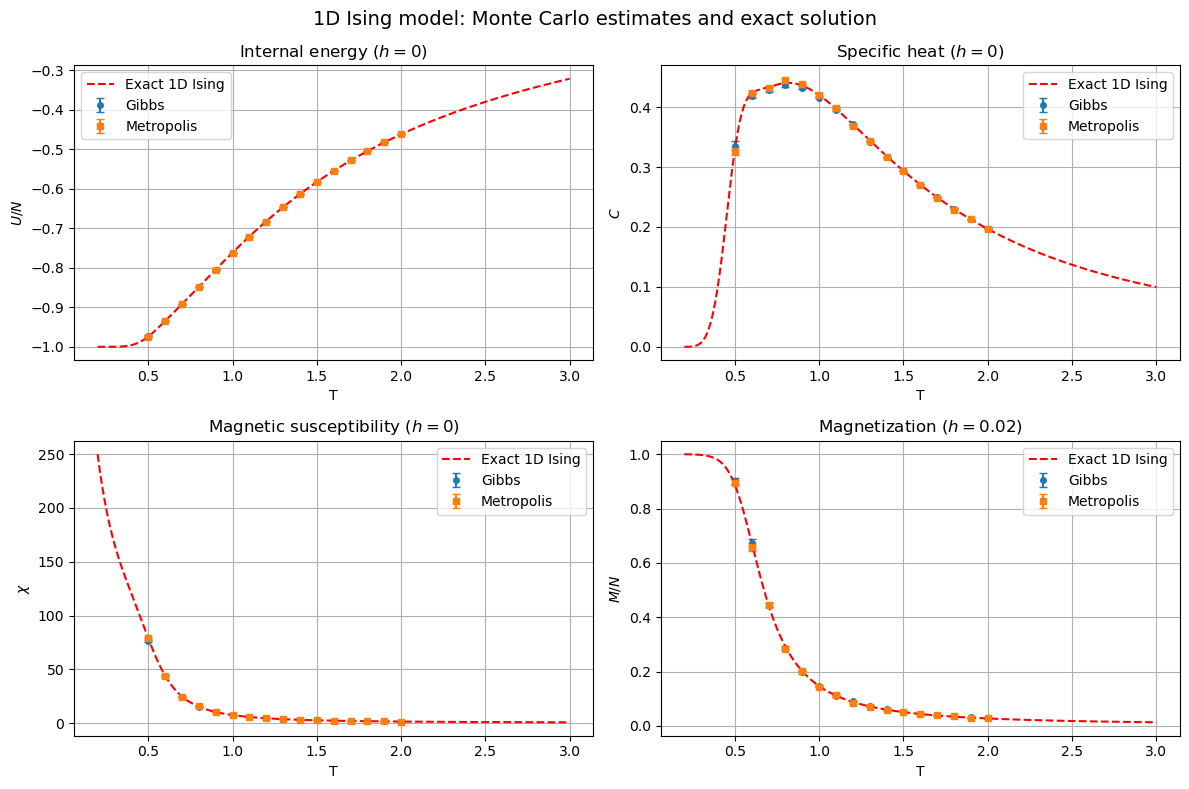

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 20 blocks, 20000 MC steps per block, for each temperature and method.
# For each temperature, the last block value is used as the final estimate with its statistical uncertainty.


# Temperatures used in the production runs
temperature_list = np.round(np.arange(0.5, 2.0 + 0.1, 0.1), 1)

base_path_gibbs = "Different_temperatures_output_gibbs"
base_path_metropolis = "Different_temperatures_output_metropolis"

def read_data(base_path, temperature_list, filename, columns):
    """Read the final progressive average and uncertainty for each temperature."""
    T_plot, ave_list, error_list = [], [], []

    for T in temperature_list:
        folder = f"T_{T:.1f}"
        file_path = os.path.join(base_path, folder, filename)

        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        df = pd.read_csv(file_path, sep=r"\s+", comment="#", header=None, names=columns)
        df = df.apply(pd.to_numeric, errors="coerce").dropna()

        if df.empty:
            print(f"No numerical data found in {file_path}")
            continue

        final_row = df.iloc[-1]
        T_plot.append(T)
        ave_list.append(final_row[columns[2]])
        error_list.append(final_row["ERROR"])

    return np.array(T_plot), np.array(ave_list), np.array(error_list)

T_gibbs_te, te_gibbs, err_gibbs_te = read_data(
    base_path_gibbs, temperature_list, "total_energy.dat",
    ["BLOCK", "ACTUAL_TE", "TE_AVE", "ERROR"]
)
T_metro_te, te_metro, err_metro_te = read_data(
    base_path_metropolis, temperature_list, "total_energy.dat",
    ["BLOCK", "ACTUAL_TE", "TE_AVE", "ERROR"]
)

T_gibbs_cv, cv_gibbs, err_gibbs_cv = read_data(
    base_path_gibbs, temperature_list, "specific_heat.dat",
    ["BLOCK", "ACTUAL_CV", "CV_AVE", "ERROR"]
)
T_metro_cv, cv_metro, err_metro_cv = read_data(
    base_path_metropolis, temperature_list, "specific_heat.dat",
    ["BLOCK", "ACTUAL_CV", "CV_AVE", "ERROR"]
)

T_gibbs_chi, chi_gibbs, err_gibbs_chi = read_data(
    base_path_gibbs, temperature_list, "susceptibility.dat",
    ["BLOCK", "ACTUAL_X", "X_AVE", "ERROR"]
)
T_metro_chi, chi_metro, err_metro_chi = read_data(
    base_path_metropolis, temperature_list, "susceptibility.dat",
    ["BLOCK", "ACTUAL_X", "X_AVE", "ERROR"]
)

T_gibbs_m, m_gibbs, err_gibbs_m = read_data(
    base_path_gibbs, temperature_list, "magnetization.dat",
    ["BLOCK", "ACTUAL_M", "M_AVE", "ERROR"]
)
T_metro_m, m_metro, err_metro_m = read_data(
    base_path_metropolis, temperature_list, "magnetization.dat",
    ["BLOCK", "ACTUAL_M", "M_AVE", "ERROR"]
)

# Exact 1D Ising curves
points = 200
T_theory = np.linspace(0.2, 3.0, num=points)
J = 1.0
Ns = 50
h = 0.02
beta = 1.0 / T_theory

th = np.tanh(J / T_theory)
thN = th**Ns
ch = 1.0 / th

energy_theory = -J * (th + ch * thN) / (1.0 + thN)

specific_heat_theory = ((beta * J) ** 2) * (
    ((1.0 + thN + (Ns - 1.0) * th**2 + (Ns - 1.0) * ch**2 * thN) / (1.0 + thN))
    - Ns * ((th + ch * thN) / (1.0 + thN)) ** 2
)

susceptibility_theory = beta * np.exp(2.0 * beta * J) * (1.0 - thN) / (1.0 + thN)

rad = np.sqrt(np.exp(2.0 * beta * J) * np.cosh(beta * h)**2 - 2.0 * np.sinh(2.0 * beta * J))
lambda_1 = np.exp(beta * J) * np.cosh(beta * h) + rad
lambda_2 = np.exp(beta * J) * np.cosh(beta * h) - rad
Z = lambda_1**Ns + lambda_2**Ns

magnetization_theory = (
    np.exp(beta * J) * np.sinh(beta * h) *
    (
        lambda_1**(Ns - 1.0) * (1.0 + np.exp(beta * J) * np.cosh(beta * h) / rad)
        + lambda_2**(Ns - 1.0) * (1.0 - np.exp(beta * J) * np.cosh(beta * h) / rad)
    )
) / Z

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

plots = [
    (axs[0, 0], T_gibbs_te, te_gibbs, err_gibbs_te, T_metro_te, te_metro, err_metro_te,
     energy_theory, "Internal energy ($h=0$)", "$U/N$"),
    (axs[0, 1], T_gibbs_cv, cv_gibbs, err_gibbs_cv, T_metro_cv, cv_metro, err_metro_cv,
     specific_heat_theory, "Specific heat ($h=0$)", "$C$"),
    (axs[1, 0], T_gibbs_chi, chi_gibbs, err_gibbs_chi, T_metro_chi, chi_metro, err_metro_chi,
     susceptibility_theory, "Magnetic susceptibility ($h=0$)", "$\\chi$"),
    (axs[1, 1], T_gibbs_m, m_gibbs, err_gibbs_m, T_metro_m, m_metro, err_metro_m,
     magnetization_theory, "Magnetization ($h=0.02$)", "$M/N$"),
]

for ax, Tg, yg, eg, Tm, ym, em, y_theory, title, ylabel in plots:
    ax.errorbar(Tg, yg, yerr=eg, fmt="o", markersize=4, capsize=3, label="Gibbs")
    ax.errorbar(Tm, ym, yerr=em, fmt="s", markersize=4, capsize=3, label="Metropolis")
    ax.plot(T_theory, y_theory, "r--", label="Exact 1D Ising")
    ax.set_xlabel("T")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

plt.suptitle("1D Ising model: Monte Carlo estimates and exact solution", fontsize=14)
plt.tight_layout()
plt.show()

### Comment

The numerical estimates obtained with both Metropolis and Gibbs sampling are **statistically compatible** with the exact analytical curves. This indicates that both methods correctly sample the same equilibrium Boltzmann distribution after equilibration.

The most visible **deviations** from the exact curves are observed at the **lowest temperatures**. This can be understood qualitatively from the behaviour of the Monte Carlo dynamics in this regime. At low temperature, configurations with lower energy are strongly favoured, so the system tends to remain close to ordered states, where many neighbouring spins are aligned.

In the Metropolis algorithm, this effect appears directly in the acceptance probability. If a proposed spin flip increases the energy, it is accepted with probability $e^{-\beta\Delta E}$. Since at low temperature $T$ is small and $\beta=1/T$ is large, this probability becomes very small for $\Delta E>0$. Therefore, many spin flips that would break the ordered structure are rejected.
In Gibbs sampling there is no rejection step, but the conditional probability becomes strongly biased toward the spin direction favoured by the neighbouring spins and by the local field. As a consequence, also in this case, successive configurations can remain very similar in the low-temperature region.

For these reasons, the exploration of the configuration space can be less efficient at low temperature. The sampled configurations can be more correlated, so the simulation effectively contains less independent information than the total number of Monte Carlo steps may suggest. Finite statistics, autocorrelation effects and possible residual equilibration effects can therefore have a more visible impact on the estimates.

A further possible contribution comes from the **restart** procedure. When `RESTART = 1`, the simulation starts from the configuration saved at the end of a previous run and uses a shorter equilibration stage. This is useful because the starting configuration is already reasonable, but after changing temperature a small residual dependence on the previous configuration may remain, especially at low temperature.

Overall, the deviations are small and do not change the main conclusion: both Metropolis and Gibbs reproduce the exact analytical curves within the statistical uncertainties.